## **1: Import Libraries & Load Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('/content/drive/My Drive/Kakuma/kakuma_youth_unemployment.csv')

In [7]:
#View the datasets
df.head()

,individual_id,age,gender,education_level,vocational_training_completed,employment_status,years_in_camp,ngo_livelihood_program_participation,access_to_microfinance,access_to_savings_group,owns_business,number_of_dependents,digital_skills_level,movement_restriction_perceived,access_to_market_opportunities,primary_employment_barrier,job_search_duration_months,monthly_income_kes,financial_stability_score
0,1,24,Female,NaN,No,Employed,16,Yes,No,Yes,Yes,0,High,Moderate,Fair,Discrimination,10.0,15150.0,99.0
1,2,32,Female,University,No,unemployed,13,No,No,Yes,No,5,Low,Moderate,Good,Movement Restriction,21.0,10043.0,76.0
2,3,28,Male,Secondary,Yes,Employed,4,No,Yes,No,No,5,Medium,High,Poor,Low Market Demand,16.0,18901.0,100.0
3,4,25,Female,College,No,Employed,6,Yes,No,Yes,Yes,2,High,Moderate,Poor,Limited Education,NaN,11123.0,64.0
4,5,24,male,NaN,Yes,Unemployed,15,Yes,No,No,No,4,Low,Low,Good,No Work Permit,19.0,8448.0,63.0


In [8]:
# View basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23437 entries, 0 to 23436
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   individual_id                         23437 non-null  int64  
 1   age                                   23437 non-null  int64  
 2   gender                                23437 non-null  object 
 3   education_level                       18854 non-null  object 
 4   vocational_training_completed         23437 non-null  object 
 5   employment_status                     23437 non-null  object 
 6   years_in_camp                         23437 non-null  int64  
 7   ngo_livelihood_program_participation  23437 non-null  object 
 8   access_to_microfinance                23437 non-null  object 
 9   access_to_savings_group               23437 non-null  object 
 10  owns_business                         23437 non-null  object 
 11  number_of_depen

In [9]:
df.shape

(23437, 19)

## **2: Standardize Column Names**

In [10]:
df.columns= df.columns.str.strip().str.lower()
df.columns= df.columns.str.replace(" ", "_")
df.columns= df.columns.str.replace("-", "_")

## **3: Clean Categorical Text Columns**

In [11]:
df['gender'].unique()

array(['Female', 'Male', 'male', 'Other', 'female'], dtype=object)

In [12]:
#changeing Gender in lower case
df["gender"]= df['gender'].str.strip().str.lower()
df["gender"]= df["gender"].replace({
    "male": "Male",
    "female": "Female",
    "other": "Other"
})

In [13]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

**Standardize Education Level**

In [14]:
#Finding a missing value in education level
df['education_level'].isna().sum()


np.int64(4583)

In [15]:
df['education_level'].unique()

array([nan, 'University', 'Secondary', 'College', 'secondary', 'Primary',
       'TVET'], dtype=object)

In [16]:
#Replace the Education value
df["education_level"]= df["education_level"].str.strip().str.title()
df['education_level']= df["education_level"].replace({
    'Secondary': 'Secondary',
    'secondary': 'Secondary',
    'TvET': 'TVET'
})

In [17]:
df["education_level"].unique()

array([nan, 'University', 'Secondary', 'College', 'Primary', 'Tvet'],
      dtype=object)

**Replace missing education:**

In [18]:
# Step 1: For rows where education_level is NaN AND vocational_training_completed == 'Yes'
# → assign TVET
df.loc[
    (df['education_level'].isna()) & (df['vocational_training_completed'] == 'Yes'),
    'education_level'
] = 'Tvet'

# Verify
df['education_level'].isna().sum()

np.int64(2717)

In [19]:
df['education_level'].unique()

array([nan, 'University', 'Secondary', 'College', 'Tvet', 'Primary'],
      dtype=object)

In [20]:
# Step 2: Forward fill then backward fill for remaining NaNs
df['education_level'] = df['education_level'].ffill().bfill()

# Verify
df['education_level'].isna().sum()

np.int64(0)

In [21]:
df['education_level'].unique()

array(['University', 'Secondary', 'College', 'Tvet', 'Primary'],
      dtype=object)

**Standardize Employment status Level**

In [22]:
df['employment_status'].unique()

array(['Employed', 'unemployed', 'Unemployed', 'Self-employed'],
      dtype=object)

In [23]:
df['employment_status'] = df['employment_status'].str.strip().str.title()
df['employment_status'] = df['employment_status'].replace({
    'Employed': 'Employed',
    'unemployed': 'Unemployed',
})

In [24]:
df['employment_status'].unique()

array(['Employed', 'Unemployed', 'Self-Employed'], dtype=object)

## **4: Clean Monthly Income Column**

In [25]:
#Remove "KES" and commas:
df['monthly_income_kes'] =(
    df['monthly_income_kes']
    .str.replace('KES', '')
    .str.replace(',', '')
)

In [26]:
df['monthly_income_kes']= pd.to_numeric(df['monthly_income_kes'], errors='coerce')

In [27]:
df['monthly_income_kes'].isnull().sum()

np.int64(0)

## **5: Handle Missing Numeric Values**

In [28]:
df.isna().sum()

,0
individual_id,0
age,0
gender,0
education_level,0
vocational_training_completed,0
employment_status,0
years_in_camp,0
ngo_livelihood_program_participation,0
access_to_microfinance,0
access_to_savings_group,0


**digital_skills_level — fill missing with the most frequent value(mode)**


In [29]:
df['digital_skills_level']= df['digital_skills_level'].fillna(df['digital_skills_level'].mode()[0])

In [30]:
df['digital_skills_level'].isnull().sum()

np.int64(0)

**job_search_duration_months — fill missing with the most frequent value(mode)**

In [31]:
df['job_search_duration_months'] = df['job_search_duration_months'].replace(0, np.nan)
df['job_search_duration_months'] = df['job_search_duration_months'].fillna(df['job_search_duration_months'].median())
df['job_search_duration_months'] = df['job_search_duration_months'].clip(lower=1, upper=12).astype(int)

In [32]:
df['job_search_duration_months'].value_counts().sort_index()

,count
job_search_duration_months,
1,981
2,883
3,876
4,871
5,880
6,878
7,892
8,892
9,936


## **6: Standardize Yes/No Columns**

In [33]:
yes_no_colunms = [
      'vocational_training_completed',
    'ngo_livelihood_program_participation',
    'access_to_microfinance',
    'access_to_savings_group',
    'owns_business'
]

for col in yes_no_colunms:
  df[col] = df[col].str.strip().str.title()

## **7: Clean Digital Skills Column**

In [34]:
df['digital_skills_level'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

## **8: Remove Duplicates**

In [35]:
#Check duplicate
df.duplicated().sum()

np.int64(317)

In [36]:
df[df.duplicated(keep=False)]

,individual_id,age,gender,education_level,vocational_training_completed,employment_status,years_in_camp,ngo_livelihood_program_participation,access_to_microfinance,access_to_savings_group,owns_business,number_of_dependents,digital_skills_level,movement_restriction_perceived,access_to_market_opportunities,primary_employment_barrier,job_search_duration_months,monthly_income_kes,financial_stability_score
52,53,19,Male,Secondary,No,Unemployed,13,No,No,No,No,0,Low,Moderate,Good,No Work Permit,7,6822.0,58.0
134,135,26,Female,Tvet,No,Employed,10,No,No,No,No,4,Medium,High,Fair,No Work Permit,3,11648.0,90.0
167,168,34,Female,Tvet,Yes,Unemployed,14,No,Yes,No,No,5,Low,High,Poor,Lack of Capital,12,2275.0,29.0
199,200,18,Male,Secondary,No,Unemployed,9,No,No,Yes,Yes,2,Low,Moderate,Poor,Discrimination,4,4981.0,70.0
247,248,32,Male,Tvet,Yes,Unemployed,9,Yes,Yes,Yes,No,2,High,Low,Poor,Low Market Demand,8,9709.0,75.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23432,5353,23,Male,Secondary,No,Employed,4,Yes,Yes,No,No,1,High,High,Poor,Discrimination,5,7951.0,67.0
23433,7859,30,Male,Primary,No,Self-Employed,3,Yes,No,No,No,3,Medium,Low,Poor,Lack of Capital,12,10936.0,73.0
23434,13708,35,Female,Secondary,No,Employed,15,Yes,No,No,Yes,1,Low,High,Good,Lack of Capital,5,8899.0,53.0
23435,12839,27,Male,University,Yes,Self-Employed,10,No,No,Yes,No,0,Medium,High,Good,Movement Restriction,12,21647.0,100.0


In [37]:
#Drop duplicates
df= df.drop_duplicates()

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
#Checking missing values
df.isna().sum()

,0
individual_id,0
age,0
gender,0
education_level,0
vocational_training_completed,0
employment_status,0
years_in_camp,0
ngo_livelihood_program_participation,0
access_to_microfinance,0
access_to_savings_group,0


## **Save the datasets**

In [40]:
df.to_csv('/content/drive/My Drive/Kakuma/kakuma_youth_unemployment_cleaned.csv', index=False)

# **EDA (Exploratory Data Analysis)**

In [41]:
#Number of colnms and rows
df.shape

(23120, 19)

In [42]:
#Describe the datasets
df.describe()

,individual_id,age,years_in_camp,number_of_dependents,job_search_duration_months,monthly_income_kes,financial_stability_score
count,23120.000000,23120.000000,23120.000000,23120.000000,23120.000000,23120.000000,23120.000000
mean,11544.265268,26.587111,10.012803,2.484386,9.475476,9189.939663,64.569810
std,6666.000329,5.213080,5.491478,1.712882,3.624021,5116.105390,24.926003
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,5771.750000,22.000000,5.000000,1.000000,7.000000,5346.000000,46.000000
50%,11543.500000,27.000000,10.000000,2.000000,12.000000,9203.000000,66.000000
75%,17317.250000,31.000000,15.000000,4.000000,12.000000,12883.250000,86.000000
max,23091.000000,35.000000,19.000000,5.000000,12.000000,28026.000000,100.000000


In [43]:
#Number of employers
df['employment_status'].value_counts()

,count
employment_status,
Unemployed,10527
Employed,8088
Self-Employed,4505


In [44]:
#Number of education level
df['education_level'].value_counts()

,count
education_level,
Secondary,7120
Tvet,5551
College,3577
Primary,3466
University,3406


In [45]:

#Number of gender
df['gender'].value_counts()

,count
gender,
Male,11616
Female,11025
Other,479


**UNEMPLOYMENT RATE**

In [46]:
df['employment_status'].unique()

array(['Employed', 'Unemployed', 'Self-Employed'], dtype=object)

In [47]:
unemployement_rate=(
    df[df['employment_status'] == 'Unemployed']['employment_status'].value_counts() / df['employment_status'].value_counts() * 100
)

In [49]:
unemployement_rate

,count
employment_status,
Employed,NaN
Self-Employed,NaN
Unemployed,100.0


**Then breakdown by gender**

In [50]:
gender_employment= pd.crosstab(
    df['gender'],
    df['employment_status'],
    margins=True,
    normalize='index'
) * 100
gender_employment

employment_status,Employed,Self-Employed,Unemployed
gender,,,
Female,35.256236,18.748299,45.995465
Male,34.607438,20.161846,45.230716
Other,37.787056,20.041754,42.171190
All,34.982699,19.485294,45.532007


**CREATE AGE GROUPS (Very Important)**

**Youth analysis requires grouping.**

In [51]:
bins=[17, 24, 34, 44]
labels=['18-24', '25-34', '35-44']
df['age_group']= pd.cut(df['age'], bins=bins, labels=labels)
df['age_group'].value_counts()

,count
age_group,
25-34,12940
18-24,8885
35-44,1295


**Now unemployment by age group:**

In [52]:
age_group_employment_status= pd.crosstab(
    df['age_group'],
    df['employment_status'],
    normalize='index'
) * 100
age_group_employment_status

employment_status,Employed,Self-Employed,Unemployed
age_group,,,
18-24,34.867755,19.696117,45.436128
25-34,35.030912,19.296754,45.672334
35-44,35.289575,19.922780,44.787645


**EDUCATION VS EMPLOYMENT**

In [53]:
education_employment_status= pd.crosstab(
    df['education_level'],
    df['employment_status'],
    normalize='index'
) * 100
education_employment_status.sort_values(by='Unemployed', ascending=False)

employment_status,Employed,Self-Employed,Unemployed
education_level,,,
University,33.323547,19.906048,46.770405
Tvet,34.534318,18.789407,46.676275
Secondary,35.140449,19.073034,45.786517
Primary,35.603001,19.878823,44.518177
College,36.343304,20.603858,43.052838


**INCOME ANALYSIS**

In [54]:
df['monthly_income_kes'].describe()

,monthly_income_kes
count,23120.000000
mean,9189.939663
std,5116.105390
min,0.000000
25%,5346.000000
50%,9203.000000
75%,12883.250000
max,28026.000000


## Income by Education

In [55]:
#Income by education
income_education= df.groupby('education_level')['monthly_income_kes'].mean()
income_education.sort_index(ascending=False)

,monthly_income_kes
education_level,
University,11412.479448
Tvet,8827.526572
Secondary,8635.357022
Primary,7501.437680
College,10376.062343


### income by vocational training

In [56]:
#income by vocational training
income_vocational_training= df.groupby('vocational_training_completed')['monthly_income_kes'].mean()
income_vocational_training

,monthly_income_kes
vocational_training_completed,
No,8638.714575
Yes,10010.842485


## BARRIERS

Top employment barriers:

In [57]:
df['primary_employment_barrier'].value_counts()

,count
primary_employment_barrier,
Movement Restriction,3917
Lack of Capital,3896
No Work Permit,3859
Discrimination,3858
Low Market Demand,3844
Limited Education,3746


In [58]:
#By Gender
pd.crosstab(df['gender'], df['primary_employment_barrier'])

primary_employment_barrier,Discrimination,Lack of Capital,Limited Education,Low Market Demand,Movement Restriction,No Work Permit
gender,,,,,,
Female,1834,1853,1786,1841,1853,1858
Male,1938,1963,1889,1919,1987,1920
Other,86,80,71,84,77,81


# **1: Unemployment Rates Across Demographics**

**1A. Unemployment by Gender (Bar Chart)**

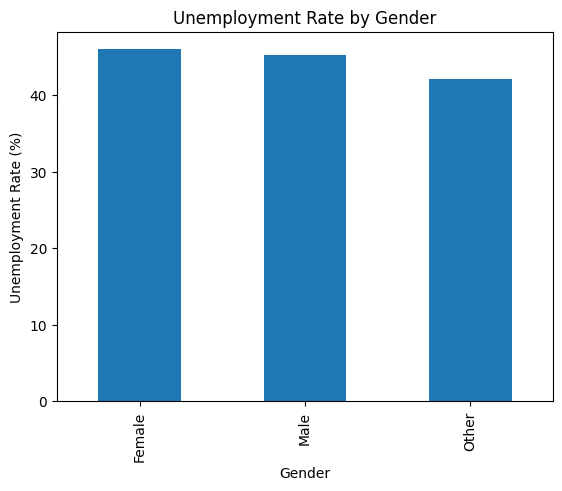

In [59]:
gender_plot = pd.crosstab(
    df['gender'],
    df['employment_status'],
    normalize='index'
) * 100
gender_plot['Unemployed'].plot(kind='bar')
plt.title('Unemployment Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Unemployment Rate (%)')
plt.show()

**1B. Unemployment by Age Group**

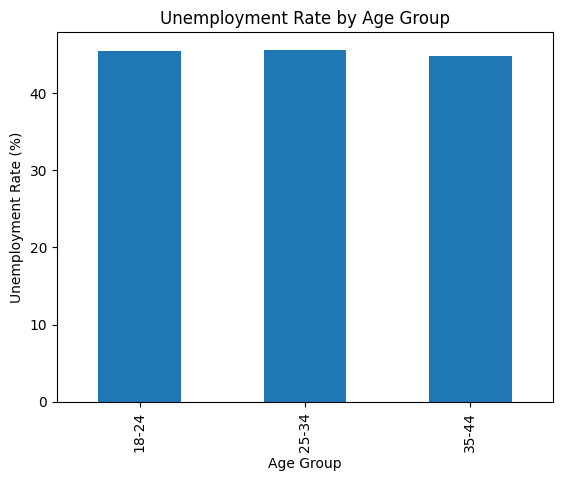

In [61]:
age_plot = pd.crosstab(
    df['age_group'],
    df['employment_status'],
    normalize='index'
) * 100
age_plot['Unemployed'].plot(kind='bar')
plt.title('Unemployment Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Unemployment Rate (%)')
plt.show()

**1C. Unemployment by Education Level**

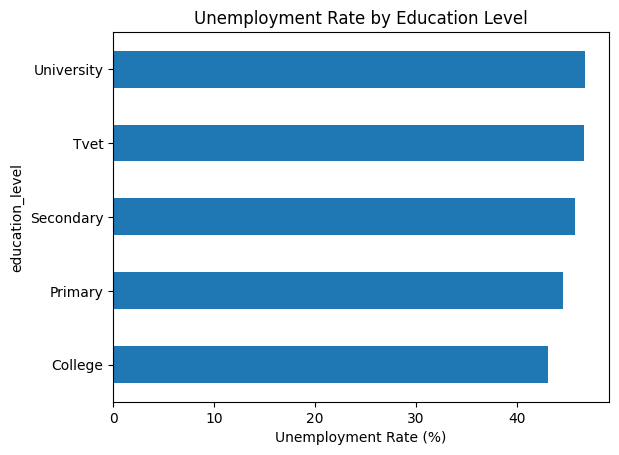

In [62]:
education_plot = pd.crosstab(
    df['education_level'],
    df['employment_status'],
    normalize='index'
) * 100
education_plot['Unemployed'].sort_values().plot(kind='barh')
plt.title('Unemployment Rate by Education Level')
plt.xlabel('Unemployment Rate (%)')
plt.show()

# **2: Education / Training vs Income**

**2A. Income by Education Level (Boxplot)**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

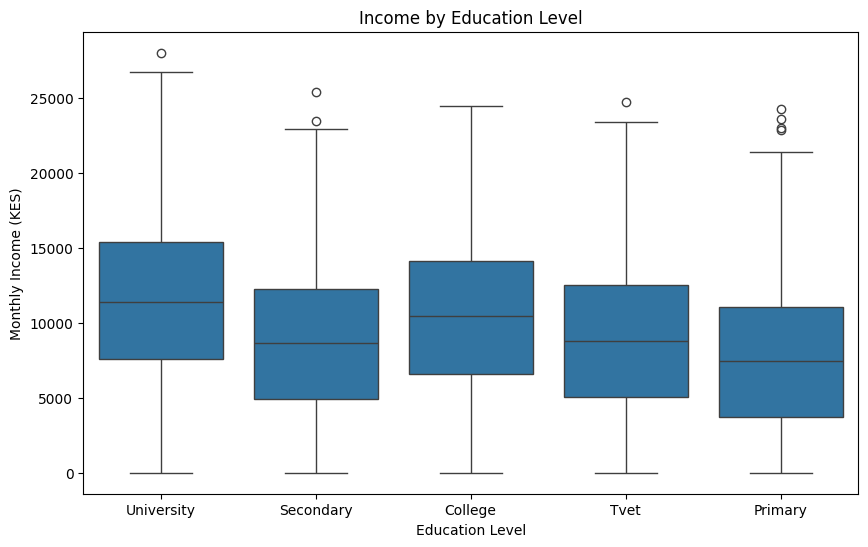

In [63]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='education_level',
    y='monthly_income_kes',
    data=df
)
plt.title('Income by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Monthly Income (KES)')
plt

**2B. Vocational Training vs Income**

Text(0, 0.5, 'Monthly Income (KES)')

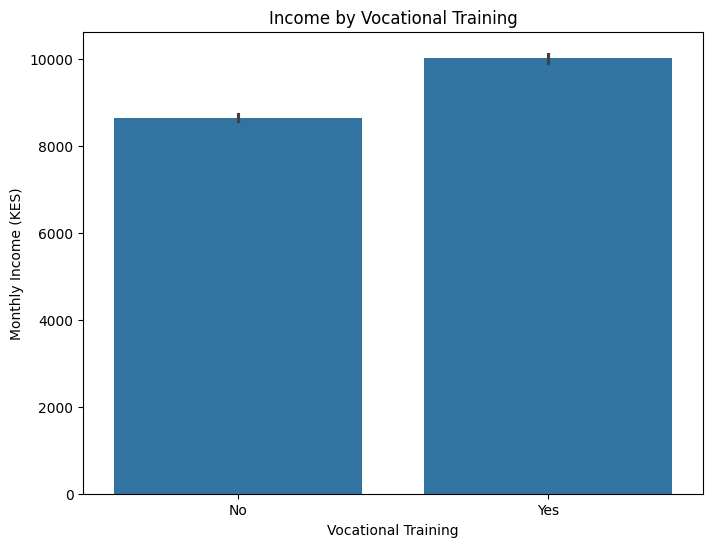

In [65]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='vocational_training_completed',
    y='monthly_income_kes',
    data=df
)
plt.title('Income by Vocational Training')
plt.xlabel('Vocational Training')
plt.ylabel('Monthly Income (KES)')

# **3: NGO Programs + Financial Access**

**NGO Participation Pie Chart**

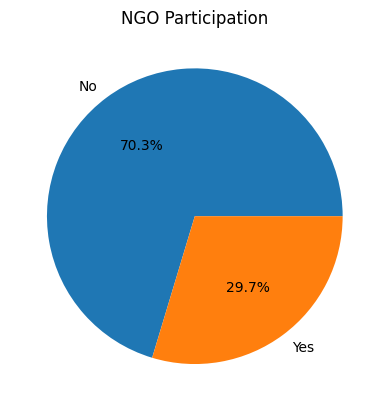

In [66]:
ngo_counts = df['ngo_livelihood_program_participation'].value_counts()
plt.pie(
    ngo_counts,
    labels=ngo_counts.index,
    autopct='%1.1f%%',
)
plt.title('NGO Participation')
plt.show()

**Microfinance Access**

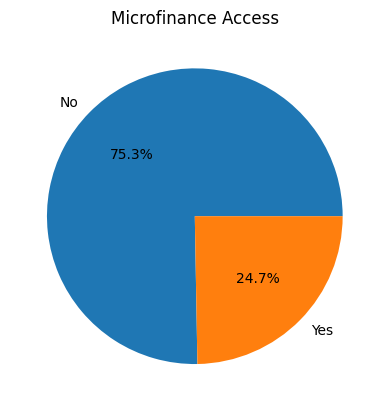

In [67]:
microfinance = df['access_to_microfinance'].value_counts()
plt.pie(
    microfinance,
    labels=microfinance.index,
    autopct='%1.1f%%',
)

plt.title('Microfinance Access')
plt.show()

# **4: Structural Barriers**

**Top Barriers Horizontal Bar Chart**

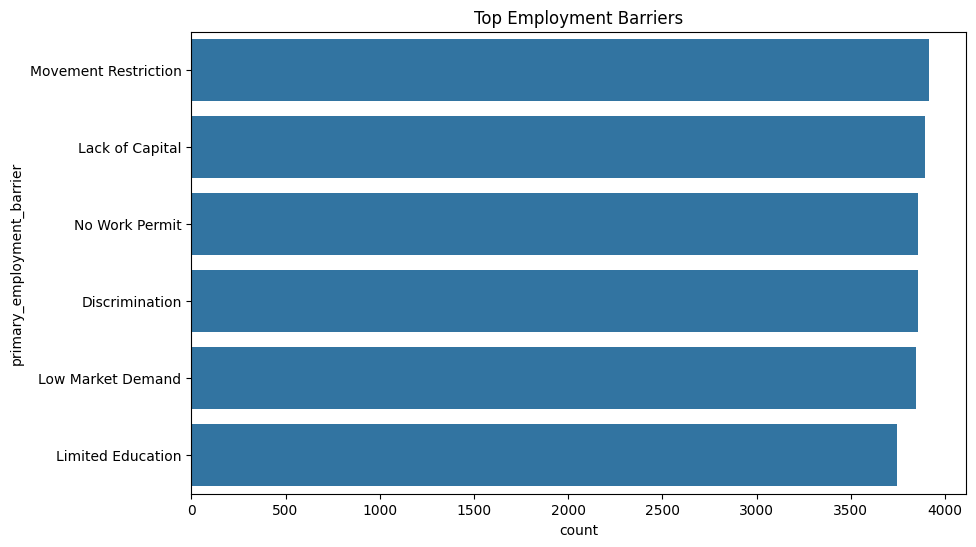

In [69]:
plt.figure(figsize=(10,6))
sns.countplot(
    y='primary_employment_barrier',
    data=df,
    order=df['primary_employment_barrier'].value_counts().index
)
plt.title('Top Employment Barriers')
plt.show()

**Barrier by Gender**

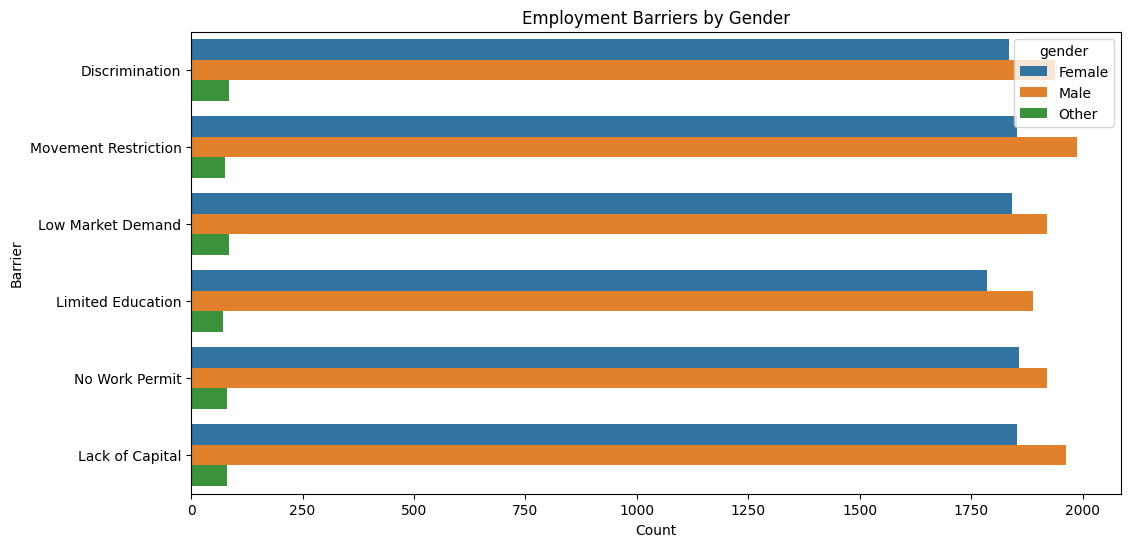

In [72]:
plt.figure(figsize=(12, 6))
sns.countplot(
    y='primary_employment_barrier',
    hue='gender',
    data=df,
)
plt.title('Employment Barriers by Gender')
plt.xlabel('Count')
plt.ylabel('Barrier')
plt.show()